In [12]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import os 

train_data_pl = pl.read_csv(r"../data/train.csv",encoding="shift_jis")

In [13]:
train_data_pl.head(1)

sample number,species number,樹種,含水率,9993.76781,9989.9107,9986.05359,9982.19648,9978.33937,9974.48227,9970.62516,9966.76805,9962.91094,9959.05383,9955.19672,9951.33962,9947.48251,9943.6254,9939.76829,9935.91118,9932.05407,9928.19697,9924.33986,9920.48275,9916.62564,9912.76853,9908.91142,9905.05432,9901.19721,9897.3401,9893.48299,9889.62588,9885.76877,9881.91166,9878.05456,9874.19745,9870.34034,…,4138.67729,4134.82018,4130.96307,4127.10596,4123.24886,4119.39175,4115.53464,4111.67753,4107.82042,4103.96331,4100.10621,4096.2491,4092.39199,4088.53488,4084.67777,4080.82066,4076.96356,4073.10645,4069.24934,4065.39223,4061.53512,4057.67801,4053.82091,4049.9638,4046.10669,4042.24958,4038.39247,4034.53536,4030.67826,4026.82115,4022.96404,4019.10693,4015.24982,4011.39271,4007.5356,4003.6785,3999.82139
i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1,1,"""イチョウ""",216.129032,0.41485,0.41465,0.41463,0.41476,0.41481,0.4147,0.41452,0.41427,0.41392,0.41364,0.41354,0.41355,0.41352,0.41337,0.41312,0.41284,0.4127,0.41265,0.41257,0.41242,0.4123,0.41226,0.41218,0.41193,0.41159,0.41129,0.41111,0.41102,0.41096,0.41098,0.41109,0.41116,0.41104,…,1.1985,1.19969,1.20339,1.20819,1.21138,1.21194,1.21262,1.21483,1.21592,1.21666,1.22043,1.22559,1.22777,1.22751,1.22862,1.23165,1.23629,1.24109,1.24147,1.23927,1.24074,1.24282,1.24082,1.23906,1.24128,1.24471,1.24783,1.25104,1.24925,1.24145,1.2362,1.23384,1.22981,1.22818,1.23087,1.23354,1.23219


In [14]:
import importlib
#import ml_pipeline
from ml_pipeline import FeatureEngineer
from ml_pipeline import FullPipelineModel
from ml_pipeline import MoisturePipeline
import mlflow
import pickle

In [15]:
#リロード
importlib.reload(ml_pipeline)

NameError: name 'ml_pipeline' is not defined

In [16]:
mlflow.set_tracking_uri("http://mlflow:5000")
mlflow.set_experiment("exp3")

<Experiment: artifact_location='/mlruns/1', creation_time=1776638985309, experiment_id='1', last_update_time=1776638985309, lifecycle_stage='active', name='exp3', tags={}>

In [17]:
with mlflow.start_run() as run:
    pipe_path = "pipe.pkl"

    pipe = MoisturePipeline(
        use_pca=True,
        use_diff=False,
        use_conv=False,
        use_band=False,
        use_sg=True,
        params={
        "verbosity": -1,
        "n_estimators": 100,
        "learning_rate": 0.03,
        "num_leaves": 6,
        "max_depth": 3,
        "min_data_in_leaf": 30,   #重要
        "feature_fraction": 0.7,
        "bagging_fraction": 0.7,
        "bagging_freq": 1,
        "n_jobs": -1,
        }
    )

    rmse = pipe.fit(train_data_pl)

    with open("pipe.pkl", "wb") as f:#保存用
        pickle.dump(pipe, f)
        
    assert os.path.exists(pipe_path)
    
    mlflow.log_artifact(pipe_path)
    mlflow.log_params({
        **pipe.params,
        "use_conv": pipe.use_conv,
        "use_diff": pipe.use_diff,
        "use_band": pipe.use_band,
        "use_pca": pipe.use_pca,
    })
    mlflow.log_metric("rmse", rmse)

    
    mlflow.pyfunc.log_model(
        python_model=FullPipelineModel(None),
        artifact_path="model",
        artifacts={"pipe": pipe_path}
    )

    
    """
    try:
        mlflow.pyfunc.log_model(
            name="model",
            python_model=FullPipelineModel(None),
            #artifact_path="model",
            artifacts={"pipe": pipe_path}
        )
    except:
        print("ERRROERRRRRRRRR!!!!!!")
        print("run_id:", run.info.run_id)
    """

Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml


In [18]:
run_id = run.info.run_id
print(run_id)

7aab260ae0414d9c8ddcdd81d816d05c


### sharpray値を使い　2次微分は1,特定の特徴量だけが落としている　or 2.全体的に効いていない　をみる

2次微分はほぼ効いていないので打ち切る

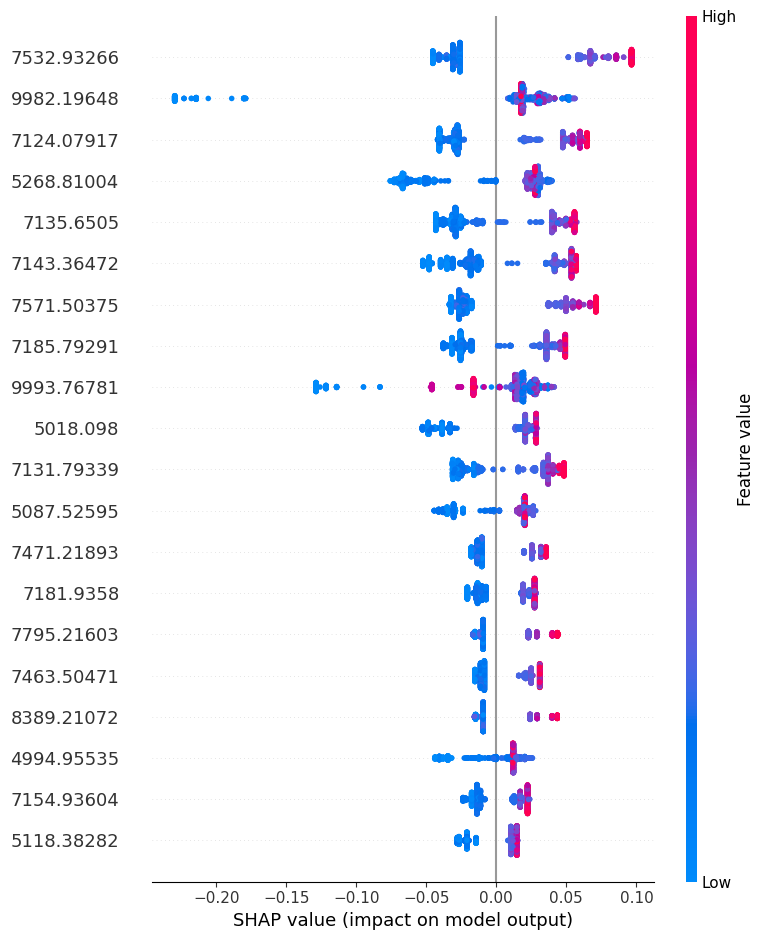


=== SHAP importance ===
7532.93266    0.047457
9982.19648    0.042915
7124.07917    0.039372
5268.81004    0.037545
7135.6505     0.036746
7143.36472    0.035604
7571.50375    0.035361
7185.79291    0.032227
9993.76781    0.031246
5018.098      0.029576
7131.79339    0.029409
5087.52595    0.023655
7471.21893    0.018830
7181.9358     0.017406
7795.21603    0.016941
7463.50471    0.016619
8389.21072    0.016567
4994.95535    0.016509
7154.93604    0.016153
5118.38282    0.015950
dtype: float64


In [19]:
from ml_pipeline import FeatureEngineer  # 定義している場所からimport

# SHAP可視化

shap_importance = pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

#pipe.fe.show_shap(train_data_pl, pipe.model, pipe.feature_cols)

In [21]:
print(len(pipe.fe.feature_cols))

print(len(pipe.fe.original_base_cols))

print(len(pipe.fe.first_diff_cols))

print(len(pipe.fe.band_feature))

print(len(pipe.fe.sg_feature_cols))

1555
1555
0
0


AttributeError: 'FeatureEngineer' object has no attribute 'sg_feature_cols'


## モデルを引き落としてきて実験する

In [25]:
test_data_pl = pl.read_csv(r"../data/test.csv",encoding="shift_jis")

In [26]:
model = mlflow.pyfunc.load_model(f"runs:/{run_id}/model")
print(model._model_impl.python_model.pipe)

In [27]:
y_pred = model.predict(test_data_pl)

In [28]:
submission = pd.DataFrame({
    "id": test_data_pl["sample number"],
    "含水率": y_pred
})

submission.head()
submission.to_csv(r"../data/submission.csv",index=False,header = False)

In [30]:
!ls -altr ../data

total 23524
-rw-r--r-- 1 root root 16924076 Mar 20 09:00 train.csv
-rw-r--r-- 1 root root     4448 Mar 28 21:46 sample_submit.csv
-rw-r--r-- 1 root root  7099176 Mar 28 21:47 test.csv
-rw-r--r-- 1 root root    13750 Mar 30 22:49 pred.txt
drwxr-xr-x 8 root root      256 Mar 30 22:49 .
-rw-r--r-- 1 root root    13750 Mar 30 22:49 pred.csv
drwxr-xr-x 1 root root     4096 Apr 20 22:07 ..
-rw-r--r-- 1 root root    12393 Apr 20 22:32 submission.csv
